# KS Sandbpx


## 1. Imports and Configuration

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from qiskit import transpile, QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import StatePreparation

from pyencode import (
    encode,
    SPARSE, STEP, SQUARE, FOURIER, WALSH, LCU,
    EncodingInfo, VectorType,
)
from pyencode.config import BASIS_GATES, OPTIMIZATION_LEVEL, DECOMPOSE_REPS

N = 128
k = np.arange(N)


## 2. Helper Functions

In [2]:
def plot_vector(f, title = None, smooth=False):
    """Plot a vector with bar or smooth style."""
    fig, ax = plt.subplots(figsize=(6, 2.5))
    x = np.arange(len(f))
    if smooth:
        ax.plot(x, f, "steelblue", lw=1.5)
        ax.fill_between(x, 0, f, alpha=0.25)
    else:
        ax.bar(x, f, color="steelblue", width=0.7)

    ax.axhline(0, color="black", lw=0.8)  # x-axis line
    ax.set_xlim(-0.5, len(f) - 0.5)
    ax.set_xticks(np.arange(0, len(f), max(1, len(f) // 8)))
    ax.set_title(title)
    ax.set_xlabel("index $i$")
    plt.tight_layout(); plt.show()

def verify_circuit(circuit, info, label=""):
    """Simulate and verify circuit matches expected statevector."""
    sv = np.abs(np.array(Statevector(circuit)))
    print(f"{label}: gate_count={info.gate_count}, complexity={info.complexity}")
    return sv

def qiskit_gate_count(f):
    """Qiskit StatePreparation gate count on the same vector."""
    norm = np.linalg.norm(f)
    if norm < 1e-14: return 0
    sv = (f / norm).astype(complex)
    qc = QuantumCircuit(int(round(np.log2(len(f)))))
    qc.append(StatePreparation(sv), range(qc.num_qubits))
    t = transpile(qc.decompose(reps=DECOMPOSE_REPS), basis_gates=BASIS_GATES,
                  optimization_level=OPTIMIZATION_LEVEL)
    return sum(t.count_ops().values())


---
## 3. All Vector Types
### 3.1 SPARSE — Gleinig-Hoefler $\mathcal{O}(sm)$

PyEncode  v1.0.0
  Vector type : SPARSE
  N           : 128  (m = 7 qubits)
  Gate count  : 5
  Complexity  : O(s·m)
  Validated   : yes
  Gates 1q/2q : 3 / 2
  Depth       : 3
  Vector      : numpy array, shape (128,)
  Parameters  : {'loads': [{'k': 19, 'P': 1.0}, {'k': 6, 'P': -2.0}]}


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


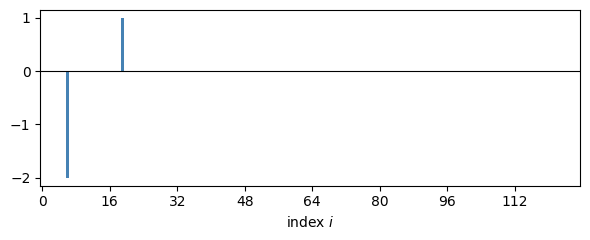

: gate_count=5, complexity=O(s·m)


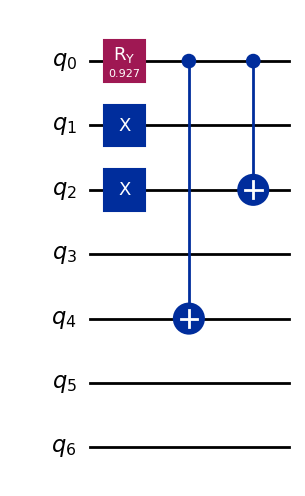

In [3]:
# s=1: motivating example from paper (index 19, N=64)
circuit, info = encode(SPARSE([(19, 1.0),(6, -2.0)]), N=N, validate=True)
print(info)
f = info.vector

plot_vector(f)
verify_circuit(circuit, info)
circuit.draw("mpl")


### 3.2 STEP — Shukla & Vedula $\mathcal{O}(m)$

PyEncode  v1.0.0
  Vector type : STEP
  N           : 128  (m = 7 qubits)
  Gate count  : 1
  Complexity  : O(m)
  Validated   : yes
  Gates 1q/2q : 1 / 0
  Vector      : numpy array, shape (128,)
  Parameters  : {'k_s': 2, 'c': 5.0}


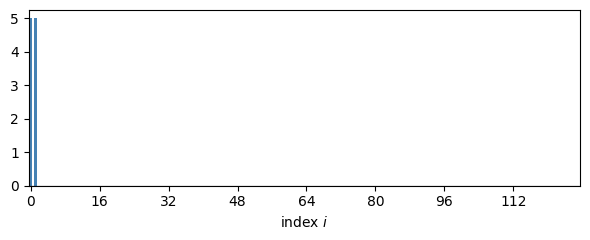

: gate_count=1, complexity=O(m)


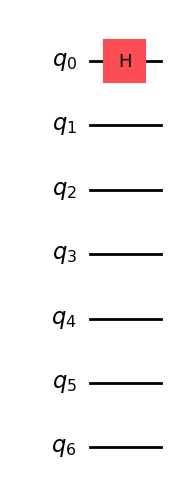

In [4]:
circuit, info = encode(STEP(k_s=2, c=5.0), N=N,validate=True)
print(info)
f = info.vector

plot_vector(f)
verify_circuit(circuit, info)
circuit.draw("mpl")


### 3.3 SQUARE — this work $\mathcal{O}(m)$

PyEncode  v1.0.0
  Vector type : SQUARE
  N           : 128  (m = 7 qubits)
  Gate count  : 22
  Complexity  : O(m)
  Validated   : yes
  Gates 1q/2q : 43 / 24
  Vector      : numpy array, shape (128,)
  Parameters  : {'k1': 8, 'k2': 44, 'c': 1.0}


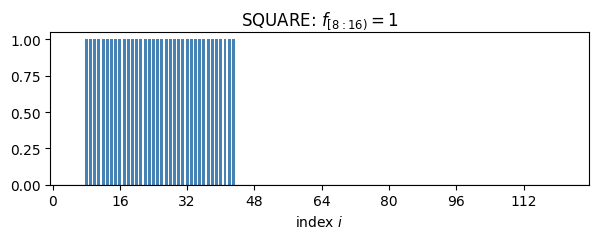

SQUARE [8,16): gate_count=22, complexity=O(m)


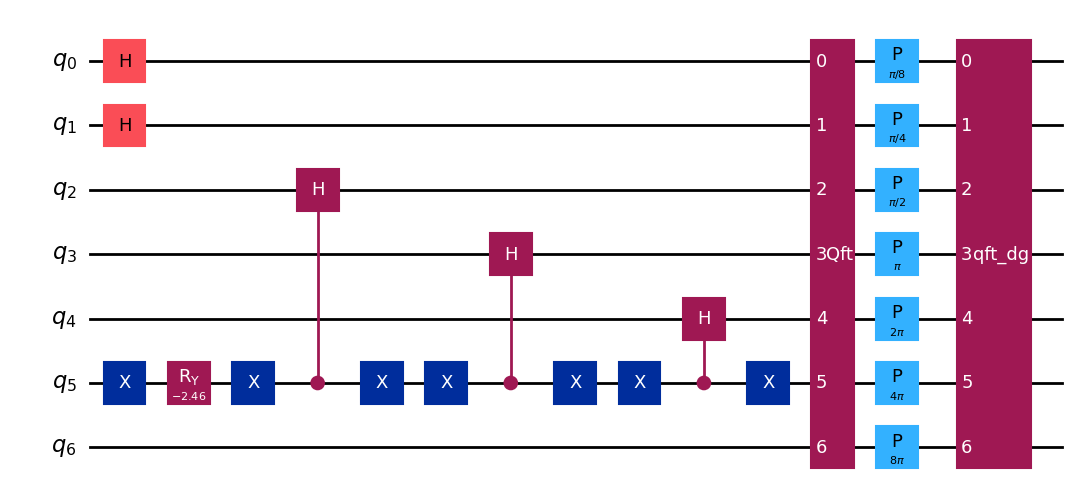

In [5]:
circuit, info = encode(SQUARE(k1=8, k2=44, c=1.0), N=N, validate=True)
print(info)

f = info.vector
plot_vector(f, r"SQUARE: $f_{[8:16)}=1$")
verify_circuit(circuit, info, "SQUARE [8,16)")
circuit.draw("mpl")


SQUARE [10,50): gate count = 20


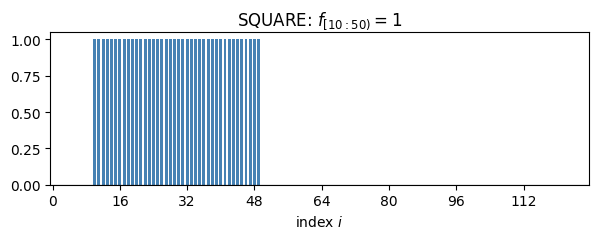

In [6]:
# Non-aligned square (general case)
circuit, info = encode(SQUARE(k1=10, k2=50, c=1.0), N=N)
print(f"SQUARE [10,50): gate count = {info.gate_count}")
f = np.zeros(N); f[10:50] = 1.0
plot_vector(f, r"SQUARE: $f_{[10:50)}=1$")


### 3.4 FOURIER — inverse QFT $\mathcal{O}(m^2)$

PyEncode  v1.0.0
  Vector type : FOURIER
  N           : 128  (m = 7 qubits)
  Gate count  : 12
  Complexity  : O(m²)
  Validated   : no
  Gates 1q/2q : 62 / 46
  Parameters  : {'modes': [{'n': 1, 'A': 1.0, 'phi': 0.0}]}


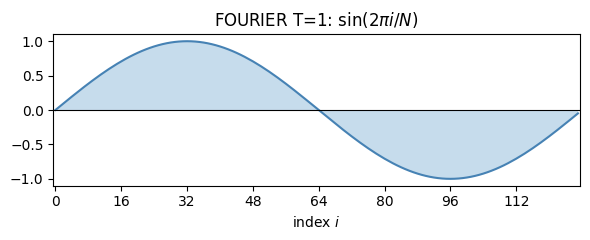

FOURIER T=1 sine: gate_count=12, complexity=O(m²)


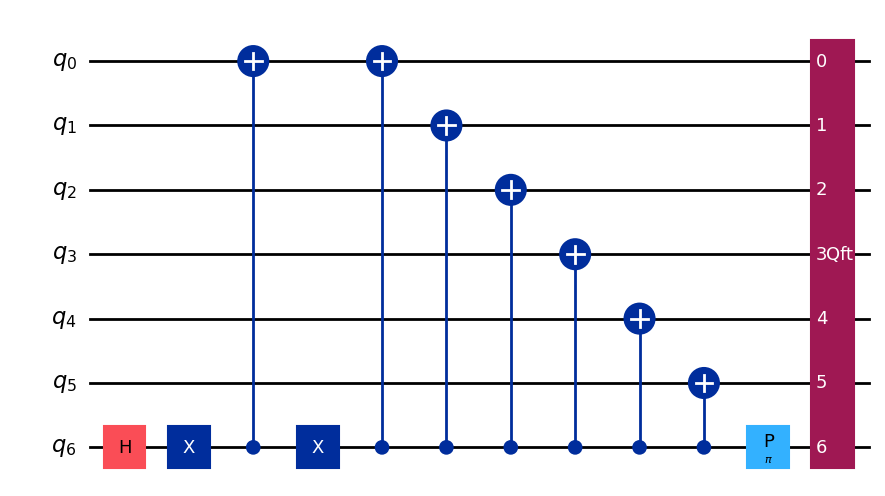

In [7]:
import math
# T=1: sine (phi=0)
circuit, info = encode(FOURIER(modes=[(1, 1.0, 0)]), N=N)
print(info)

f = np.sin(2 * np.pi * k / N)
plot_vector(f, r"FOURIER T=1: $\sin(2\pi i/N)$", smooth=True)
verify_circuit(circuit, info, "FOURIER T=1 sine")
circuit.draw("mpl")


FOURIER cosine: gate count = 12


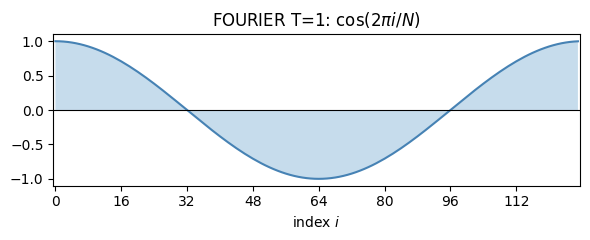

In [8]:
# T=1: cosine (phi=pi/2)
circuit, info = encode(FOURIER(modes=[(1, 1.0, math.pi/2)]), N=N)
print(f"FOURIER cosine: gate count = {info.gate_count}")

f = np.cos(2 * np.pi * k / N)
plot_vector(f, r"FOURIER T=1: $\cos(2\pi i/N)$", smooth=True)


PyEncode  v1.0.0
  Vector type : FOURIER
  N           : 128  (m = 7 qubits)
  Gate count  : 14
  Complexity  : O(m²)
  Validated   : no
  Gates 1q/2q : 62 / 48
  Parameters  : {'modes': [{'n': 3, 'A': 2.0, 'phi': 0.7853981633974483}]}


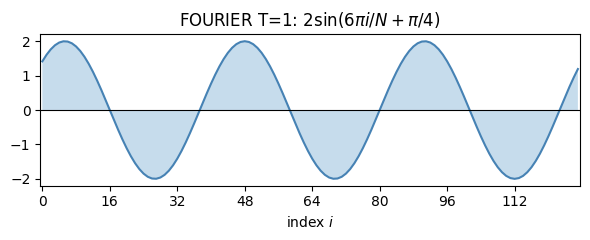

In [9]:
# T=1: n=3, phi=pi/4
circuit, info = encode(FOURIER(modes=[(3, 2.0, math.pi/4)]), N=N)
print(info)

f = 2.0 * np.sin(2 * np.pi * 3 * k / N + math.pi/4)
plot_vector(f, r"FOURIER T=1: $2\sin(6\pi i/N + \pi/4)$", smooth=True)


PyEncode  v1.0.0
  Vector type : FOURIER
  N           : 128  (m = 7 qubits)
  Gate count  : 11
  Complexity  : O(m²)
  Validated   : no
  Gates 1q/2q : 65 / 48
  Parameters  : {'modes': [{'n': 1, 'A': 2.0, 'phi': 0.0}, {'n': 3, 'A': 1.0, 'phi': 0.0}]}


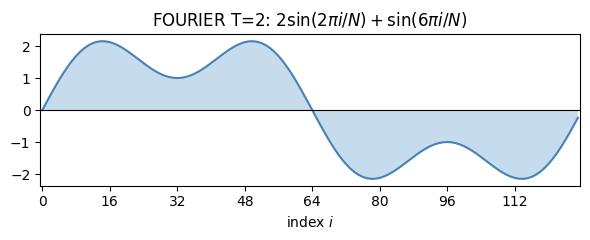

FOURIER T=2: gate_count=11, complexity=O(m²)


array([1.41379951e-17, 1.36884156e-02, 2.71860562e-02, 4.03060221e-02,
       5.28690813e-02, 6.47072968e-02, 7.56674116e-02, 8.56139176e-02,
       9.44317444e-02, 1.02028508e-01, 1.08336275e-01, 1.13312798e-01,
       1.16942204e-01, 1.19235120e-01, 1.20228223e-01, 1.19983240e-01,
       1.18585412e-01, 1.16141458e-01, 1.12777075e-01, 1.08634047e-01,
       1.03867009e-01, 9.86399403e-02, 9.31224702e-02, 8.74860705e-02,
       8.19002177e-02, 7.65286096e-02, 7.15255194e-02, 6.70323640e-02,
       6.31745636e-02, 6.00587581e-02, 5.77704439e-02, 5.63720788e-02,
       5.59016994e-02, 5.63720788e-02, 5.77704439e-02, 6.00587581e-02,
       6.31745636e-02, 6.70323640e-02, 7.15255194e-02, 7.65286096e-02,
       8.19002177e-02, 8.74860705e-02, 9.31224702e-02, 9.86399403e-02,
       1.03867009e-01, 1.08634047e-01, 1.12777075e-01, 1.16141458e-01,
       1.18585412e-01, 1.19983240e-01, 1.20228223e-01, 1.19235120e-01,
       1.16942204e-01, 1.13312798e-01, 1.08336275e-01, 1.02028508e-01,
      

In [10]:
# T=2: multi-mode
circuit, info = encode(FOURIER(modes=[(1, 2.0, 0), (3, 1.0, 0)]), N=N)
print(info)

f = 2.0*np.sin(2*np.pi*k/N) + np.sin(2*np.pi*3*k/N)
plot_vector(f, r"FOURIER T=2: $2\sin(2\pi i/N) + \sin(6\pi i/N)$", smooth=True)
verify_circuit(circuit, info, "FOURIER T=2")


### 3.5 Walsh — $(-1)^{b_k(i)}$ signed uniform superposition — $\mathcal{O}(m)$

PyEncode  v1.0.0
  Vector type : WALSH
  N           : 128  (m = 7 qubits)
  Gate count  : 8
  Complexity  : O(m)
  Validated   : no
  Gates 1q/2q : 7 / 0
  Parameters  : {'k': 0, 'c_pos': 1.0, 'c_neg': -1.0}


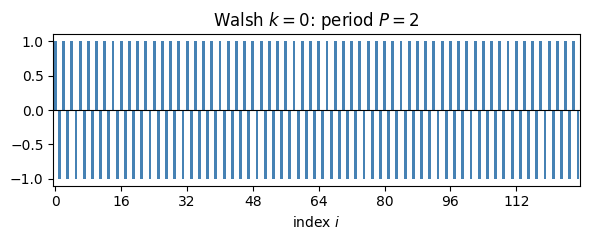

WALSH k=0: gate_count=8, complexity=O(m)


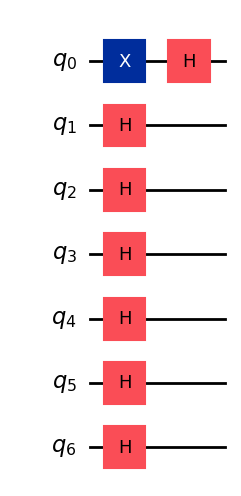

In [11]:
import math
# k=0: period 2 (fastest alternation)
circuit, info = encode(WALSH(k=0), N=N)
print(info)

f = np.array([1 if not ((i >> 0) & 1) else -1 for i in range(N)], dtype=float)
plot_vector(f, "Walsh $k=0$: period $P=2$")
verify_circuit(circuit, info, "WALSH k=0")
circuit.draw("mpl")


PyEncode  v1.0.0
  Vector type : WALSH
  N           : 128  (m = 7 qubits)
  Gate count  : 8
  Complexity  : O(m)
  Validated   : no
  Gates 1q/2q : 7 / 0
  Parameters  : {'k': 1, 'c_pos': 1.0, 'c_neg': -1.0}


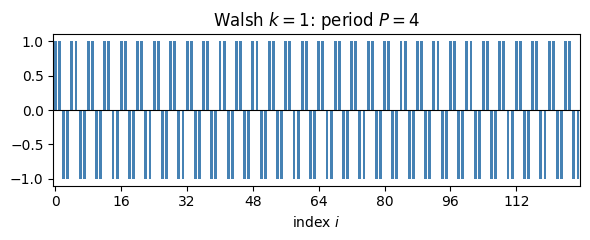

WALSH k=1: gate_count=8, complexity=O(m)


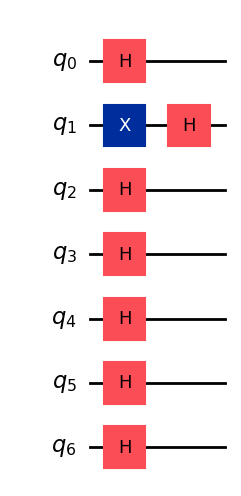

In [12]:
# k=1: period 4
circuit, info = encode(WALSH(k=1), N=N)
print(info)

f = np.array([1 if not ((i >> 1) & 1) else -1 for i in range(N)], dtype=float)
plot_vector(f, "Walsh $k=1$: period $P=4$")
verify_circuit(circuit, info, "WALSH k=1")
circuit.draw("mpl")


In [13]:
# Sweep: gate count vs qubit index k
m_bits = int(round(np.log2(N)))
print(f"m = {m_bits} qubits, N = {N}")
for k_idx in range(m_bits):
    _, info_k = encode(WALSH(k=k_idx), N=N)
    print(f"  k={k_idx}  period={2**(k_idx+1):>4}  gates={info_k.gate_count}")


m = 7 qubits, N = 128
  k=0  period=   2  gates=8
  k=1  period=   4  gates=8
  k=2  period=   8  gates=8
  k=3  period=  16  gates=8
  k=4  period=  32  gates=8
  k=5  period=  64  gates=8
  k=6  period= 128  gates=8


### 3.6 LCU — weighted superposition via Protocol 1

Prepares $|\psi\rangle \propto \sum_j w_j |\hat{f}^{(j)}\rangle$ using $\lceil\log_2 r\rceil$ ancilla qubits.
Success probability $p = \sum_{i,j} \beta_i^2 \beta_j^2 \langle\hat{f}^{(i)}|\hat{f}^{(j)}\rangle$, with $\beta_j = \sqrt{w_j\|f_j\|}/Z$.
Post-select ancilla on $|0\rangle$ to recover the pure target state.

PyEncode  v1.0.0
  Vector type : LCU
  N           : 128  (m = 7 qubits)
  Gate count  : 61
  Complexity  : O(2·m)
  Validated   : no
  Success prob: 0.6250  (post-selection required)
  Parameters  : {'components': ['SQUARE', 'SQUARE'], 'weights': [1.0, 3.0], 'disjoint': True}
Success probability: 0.6250
Ancilla qubits: 1


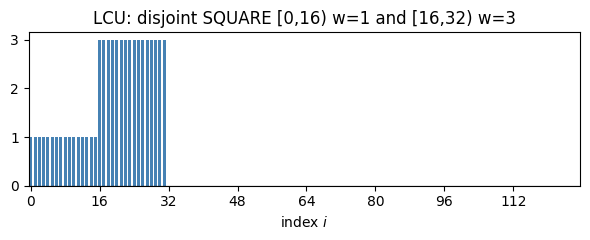

In [14]:
import warnings

# --- Disjoint SQUARE components (MULTI_SQUARE via LCU) ---
# Two disjoint intervals: p determined analytically, no warning issued
circuit, info = encode(
    LCU([(1.0, SQUARE(k1=0,  k2=16, c=1.0)),
         (3.0, SQUARE(k1=16, k2=32, c=1.0))]),
    N=N)
print(info)
print(f'Success probability: {info.success_probability:.4f}')
print(f'Ancilla qubits: {circuit.num_qubits - int(round(np.log2(N)))}')

f = np.zeros(N); f[:16] = 1.0; f[16:32] = 3.0
plot_vector(f, 'LCU: disjoint SQUARE [0,16) w=1 and [16,32) w=3')


PyEncode  v1.0.0
  Vector type : LCU
  N           : 128  (m = 7 qubits)
  Gate count  : 61
  Complexity  : O(2·m)
  Validated   : no
  Success prob: 0.5556  (post-selection required)
  Parameters  : {'components': ['STEP', 'SQUARE'], 'weights': [2.0, 1.0], 'disjoint': True}
Success probability: 0.5556


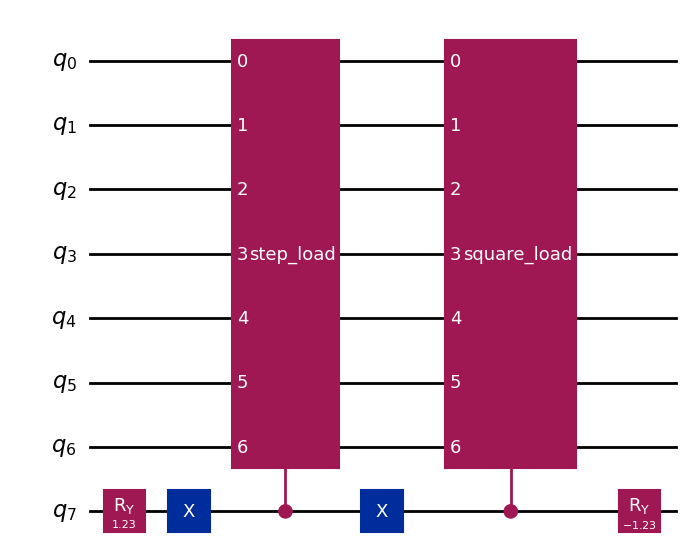

In [15]:
# --- Disjoint STEP + SQUARE ---
circuit, info = encode(
    LCU([(2.0, STEP(k_s=16, c=1.0)),
         (1.0, SQUARE(k1=16, k2=32, c=1.0))]),
    N=N)
print(info)
print(f'Success probability: {info.success_probability:.4f}')
circuit.draw('mpl')


In [16]:
# --- Overlapping components (UserWarning expected) ---
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    circuit, info = encode(
        LCU([(1.0, STEP(k_s=32, c=1.0)),
             (1.0, FOURIER(modes=[(1, 1.0, 0)]))]),
        N=N)
    if w:
        print(f'Warning: {w[0].message}')
print(info)
print(f'Success probability: {info.success_probability:.4f}')


PyEncode  v1.0.0
  Vector type : LCU
  N           : 128  (m = 7 qubits)
  Gate count  : 1287
  Complexity  : O(2·m)
  Validated   : no
  Success prob: 0.7278  (post-selection required)
  Parameters  : {'components': ['STEP', 'FOURIER'], 'weights': [1.0, 1.0], 'disjoint': False}
Success probability: 0.7278


In [17]:
# --- p vs number of components (equal weight, disjoint) ---
import math
print(f'Theoretical p = 1/r for r equal-weight disjoint components:')
for r in [2, 4, 8]:
    step = N // r
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        intervals = [(1.0, SQUARE(k1=i*step, k2=(i+1)*step, c=1.0)) for i in range(r)]
        _, info_r = encode(LCU(intervals), N=N)
    p_theory = 1/r
    print(f'  r={r}: p={info_r.success_probability:.4f}  (theory 1/r={p_theory:.4f})')


Theoretical p = 1/r for r equal-weight disjoint components:
  r=2: p=0.5000  (theory 1/r=0.5000)
  r=4: p=0.2500  (theory 1/r=0.2500)
  r=8: p=0.1250  (theory 1/r=0.1250)


### 3.5 Qiskit Fallback — unrecognized pattern

Qiskit fallback: 247 gates (O(2^m))


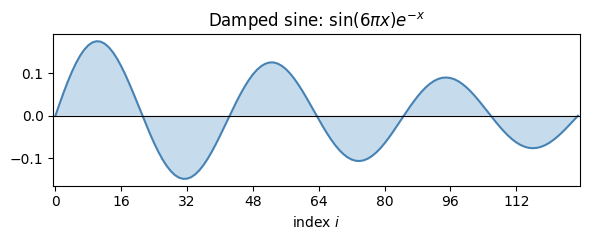

In [18]:
# Damped sine: not in the pattern library -> user falls back explicitly
x = np.linspace(0, 1, N)
f_damped = np.sin(3 * 2*np.pi * x) * np.exp(-x)
f_damped /= np.linalg.norm(f_damped)

qc = QuantumCircuit(int(np.log2(N)))
qc.append(StatePreparation(f_damped.astype(complex)), range(qc.num_qubits))
qc = qc.decompose(reps=DECOMPOSE_REPS)
t = transpile(qc, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
print(f"Qiskit fallback: {sum(t.count_ops().values())} gates (O(2^m))")
plot_vector(f_damped, r"Damped sine: $\sin(6\pi x)e^{-x}$", smooth=True)


---
## 4. Gate Count Comparison (Table in Paper)

In [19]:
def pyencode_counts(vobj):
    c, info = encode(vobj, N=N)
    raw = info.gate_count
    t = transpile(c, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    transp = sum(t.count_ops().values())
    return raw, transp, info.complexity

cases = [
    ("SPARSE s=1 (k=20)",    SPARSE([(20, 1.0)]),              np.eye(N)[20]),
    ("STEP (k_s=4)",         STEP(k_s=4, c=1.0),              np.r_[np.ones(4),  np.zeros(N-4)]),
    ("SQUARE ([8,16))",      SQUARE(k1=8, k2=16, c=1.0),      np.r_[np.zeros(8), np.ones(8), np.zeros(N-16)]),
    ("FOURIER T=1 n=1",      FOURIER(modes=[(1, 1.0, 0)]),     np.sin(2*np.pi*k/N)),
    ("FOURIER T=1 n=3 phi",  FOURIER(modes=[(3, 1.0, np.pi/4)]), np.sin(2*np.pi*3*k/N+np.pi/4)),
    ("Walsh (k=1, P=4)",      WALSH(k=1),
     np.array([1.0 if not ((idx>>1)&1) else -1.0 for idx in range(N)])),
    ("LCU r=2 disjoint",        LCU([(1.0, SQUARE(k1=0, k2=N//2, c=1.0)),
                                      (3.0, SQUARE(k1=N//2, k2=N, c=1.0))]),
     None),
    ("SPARSE s=2",                       SPARSE([(10,3.0),(50,4.0)]),      None),
]

print(f"  {'Pattern':<26} {'Raw':>6} {'Transp':>8} {'Qiskit':>8}  Complexity")
print("-" * 65)
for desc, vobj, f_ref in cases:
    raw, transp, compl = pyencode_counts(vobj)
    if f_ref is not None:
        qk = qiskit_gate_count(f_ref)
    else:
        f_ref2 = np.zeros(N); f_ref2[10]=3.0; f_ref2[50]=4.0
        qk = qiskit_gate_count(f_ref2)
    print(f"  {desc:<26} {raw:>6} {transp:>8} {qk:>8}  {compl}")


  Pattern                       Raw   Transp   Qiskit  Complexity
-----------------------------------------------------------------
  SPARSE s=1 (k=20)               2        2       38  O(s·m)
  STEP (k_s=4)                    2        2      126  O(m)
  SQUARE ([8,16))                 4        4      108  O(m)
  FOURIER T=1 n=1                12       99      247  O(m²)
  FOURIER T=1 n=3 phi            14      101      245  O(m²)
  Walsh (k=1, P=4)                8        7        9  O(m)
  LCU r=2 disjoint               89       28       86  O(2·m)
  SPARSE s=2                      6        6       86  O(s·m)


---
## 5. Application Examples
### 5.1 Quantum Chemistry: Fermi-Hubbard PREP

PyEncode  v1.0.0
  Vector type : WALSH
  N           : 16  (m = 4 qubits)
  Gate count  : 5
  Complexity  : O(m)
  Validated   : no
  Gates 1q/2q : 4 / 0
  Parameters  : {'k': 3, 'c_pos': 1.0, 'c_neg': 4.0}


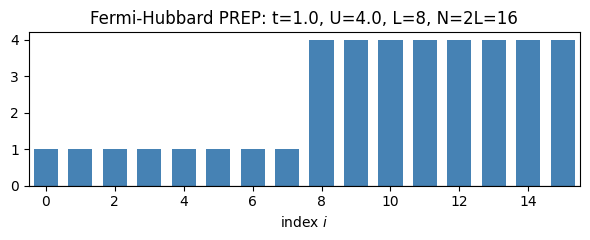

In [20]:
import math
L = 8;  t = 1.0;  U = 4.0

# Equal-block Fermi-Hubbard: L hopping + L interaction, N = 2L
# Generalized Walsh: ancilla-free, m+1 gates
circuit, info = encode(
    WALSH(k=int(math.log2(L)), c_pos=t, c_neg=U),
    N=2*L)
print(info)

f = np.zeros(2*L)
f[:L] = t; f[L:] = U
plot_vector(f, f"Fermi-Hubbard PREP: t={t}, U={U}, L={L}, N=2L={2*L}")


### 5.2 Computational Mechanics: 2D Poisson

x-register: 9 gates
y-register: 12 gates
Total: 21 gates for 1024 amplitudes


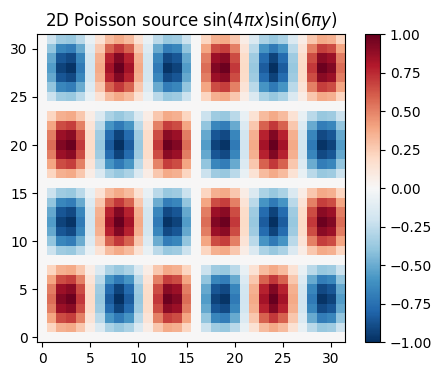

In [21]:
N_grid = 32
k_grid = np.arange(N_grid)

circ_x, info_x = encode(FOURIER(modes=[(2, 1.0, 0)]), N=N_grid)
circ_y, info_y = encode(FOURIER(modes=[(3, 1.0, 0)]), N=N_grid)
circuit = circ_x.tensor(circ_y)

print(f"x-register: {info_x.gate_count} gates")
print(f"y-register: {info_y.gate_count} gates")
print(f"Total: {info_x.gate_count + info_y.gate_count} gates for {N_grid**2} amplitudes")

u = np.sin(2*np.pi*2*k_grid/N_grid)
v = np.sin(2*np.pi*3*k_grid/N_grid)
f_2d = np.outer(u, v)
plt.figure(figsize=(5,4))
plt.imshow(f_2d, cmap="RdBu_r", origin="lower")
plt.colorbar(); plt.title(r"2D Poisson source $\sin(4\pi x)\sin(6\pi y)$")
plt.show()


### 5.3 Quantum Finance: Price Distribution

PyEncode  v1.0.0
  Vector type : SPARSE
  N           : 128  (m = 7 qubits)
  Gate count  : 28
  Complexity  : O(s·m)
  Validated   : no
  Gates 1q/2q : 44 / 31
  Parameters  : {'loads': [{'k': 8, 'P': 0.05}, {'k': 16, 'P': 0.15}, {'k': 24, 'P': 0.25}, {'k': 32, 'P': 0.3}, {'k': 40, 'P': 0.15}, {'k': 48, 'P': 0.07}, {'k': 56, 'P': 0.03}]}


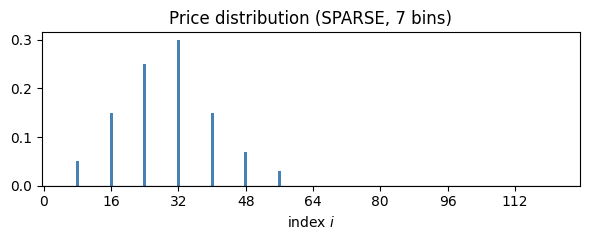

PyEncode: 28 gates  |  Qiskit: 25 gates


In [22]:
indices = [8, 16, 24, 32, 40, 48, 56]
weights = [0.05, 0.15, 0.25, 0.30, 0.15, 0.07, 0.03]

circuit, info = encode(
    SPARSE(list(zip(indices, weights))),
    N=N,
)
print(info)

f = np.zeros(N)
for k_i, w_i in zip(indices, weights): f[k_i] = w_i
plot_vector(f, "Price distribution (SPARSE, 7 bins)")

qk = qiskit_gate_count(f)
print(f"PyEncode: {info.gate_count} gates  |  Qiskit: {qk} gates")


---
## 6. Circuit Code Output

In [23]:
_, info = encode(FOURIER(modes=[(1, 1.0, 0)]), N=16)
print(info.circuit_code)


# PyEncode — emitted circuit: FOURIER — sinusoidal modes via inverse QFT
# m = 4 qubits,  N = 16 nodes
# Edit freely; run as standalone Qiskit code.

from qiskit import QuantumCircuit

import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT

m = 4
N = 2**m
k = np.arange(N)

# Build the sinusoidal vector
f = np.zeros(N)
f += 1.0 * np.sin(2 * np.pi * 1 * k / N + 0.0)

# Encode as sparse Fourier state + inverse QFT
# (circuit synthesized internally by PyEncode)
# modes = [{'n': 1, 'A': 1.0, 'phi': 0.0}]
